# Taller 3 — Analisis de Datos con Pandas, NumPy y Matplotlib
## Steam Games Dataset

**Dataset:** `SteamGames.csv` — 29 931 registros, 18 columnas  
**Objetivo:** Explorar, limpiar, analizar y visualizar el catalogo de juegos de Steam
para extraer conclusiones sobre precios, generos, reseñas y desarrolladores.

**Contenido del taller:**
- Parte 1 — Exploracion de datos
- Parte 2 — Limpieza de datos
- Parte 3 — Filtrado y seleccion de datos relevantes
- Parte 4 — Transformacion y creacion de variables nuevas
- Parte 5 — Agrupaciones y resumenes con groupby()
- Parte 6 — 5 Preguntas de analisis con graficas e interpretacion

---
**Archivo requerido:** `SteamGames.csv` en la misma carpeta que este notebook.


## Librerias e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Configuracion general de estilo para todas las graficas del taller
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Cargamos el dataset. pd.read_csv() convierte el CSV en un DataFrame de Pandas,
# que es basicamente una tabla con filas y columnas que podemos manipular desde Python.
df = pd.read_csv('SteamGames.csv')
print(f"Archivo cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas")


Archivo cargado: 29,931 filas y 18 columnas


---
## Parte 1 — Exploracion de Datos
Antes de limpiar o analizar cualquier cosa, necesitamos entender con que estamos trabajando.
Esta parte responde preguntas basicas: cuantos registros hay, que tipo de datos tiene cada columna y donde hay problemas.


### 1.1 Primeras filas del dataset

In [2]:
# head() muestra las primeras 5 filas del dataset.
# Aqui podemos ver, por ejemplo, que la columna 'price' tiene el simbolo $ pegado al numero,
# lo que significa que Python la esta tratando como texto y no como numero.
df[['Appid','Name','Type','ReleaseDate','Genres','price','ReviewScore','Rank']].head()


,Appid,Name,Type,ReleaseDate,Genres,price,ReviewScore,Rank
0,3764200,Resident Evil Requiem,game,"Feb 26, 2026","Action,Adventure",69.99$,9,1
1,730,Counter-Strike 2,game,"Aug 21, 2012","Action,Free To Play",0$,8,2
2,1808500,ARC Raiders,game,"Oct 30, 2025",Action,39.99$,8,3
3,359550,Tom Clancy's Rainbow Six Siege,game,"Dec 1, 2015","Action,Free To Play",0$,8,4
4,1172470,Apex Legends™,game,"Nov 4, 2020","Action,Adventure,Free To Play",0$,6,5


### 1.2 Informacion general del dataset

In [3]:
# df.info() nos da un resumen tecnico del dataset:
# cuantos valores no nulos tiene cada columna y que tipo de dato le asigno Pandas.
# Por ejemplo, 'price' aparece como 'str' (texto) cuando deberia ser 'float' (decimal).
# Eso es una señal de que hay que limpiar esa columna antes de operar con ella.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29931 entries, 0 to 29930
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Appid              29931 non-null  int64 
 1   Name               29931 non-null  object
 2   Type               29931 non-null  object
 3   ReleaseDate        29917 non-null  object
 4   Genres             29518 non-null  object
 5   Developers         29905 non-null  object
 6   Publishers         28886 non-null  object
 7   Description        29879 non-null  object
 8   price              29931 non-null  object
 9   Thumbnail          29931 non-null  object
 10  Tags               28317 non-null  object
 11  ReviewScore        29931 non-null  int64 
 12  PositiveReview     29931 non-null  int64 
 13  NegativeReview     29931 non-null  int64 
 14  OsRequirement      26994 non-null  object
 15  MemoryRequirement  25947 non-null  object
 16  CpuRequirement     26072 non-null  objec

### 1.3 Resumen estadistico

In [4]:
# describe() calcula automaticamente estadisticas basicas de las columnas numericas:
# cuantos valores hay, el promedio, la desviacion estandar, minimo, cuartiles y maximo.
# Aqui vemos que ReviewScore va de 0 a 9. No es un porcentaje sino un indice de categoria
# que Steam usa internamente para clasificar las reseñas (lo vamos a traducir mas adelante).
df[['ReviewScore','PositiveReview','NegativeReview','Rank']].describe()


,ReviewScore,PositiveReview,NegativeReview,Rank
count,29931.000000,2.993100e+04,29931.000000,29931.000000
mean,6.237145,1.443837e+03,193.180849,7585.978350
std,2.560245,1.368262e+04,2084.565186,4493.478798
min,0.000000,0.000000e+00,0.000000,1.000000
25%,6.000000,1.700000e+01,2.000000,3742.000000
50%,7.000000,5.900000e+01,9.000000,7483.000000
75%,8.000000,2.700000e+02,47.000000,11224.500000
max,9.000000,1.214897e+06,202393.000000,16719.000000


### 1.4 Cantidad de filas, columnas y duplicados

In [5]:
# shape nos devuelve una tupla (filas, columnas).
print(f"Filas   : {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

# duplicated().sum() cuenta cuantas filas son copias exactas de otra fila.
print(f"\nDuplicados exactos: {df.duplicated().sum()}")

# Verificamos tambien que cada Appid sea unico — confirma que no hay juegos repetidos.
print(f"Appid unicos      : {df['Appid'].nunique():,}")


Filas   : 29,931
Columnas: 18

Duplicados exactos: 0
Appid unicos      : 29,789


### 1.5 Valores nulos por columna

In [6]:
# isnull().sum() cuenta cuantos valores vacios (NaN) hay en cada columna.
# Vemos que las columnas de requisitos del sistema tienen miles de nulos.
# Eso tiene sentido porque no todos los productos del catalogo de Steam son videojuegos —
# hay musica, DLC y hardware que no tienen requisitos de sistema.
nulos = df.isnull().sum().sort_values(ascending=False)
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje del total (%)': pct})
resumen_nulos[resumen_nulos['Nulos'] > 0]


,Nulos,Porcentaje del total (%)
MemoryRequirement,3984,13.3
CpuRequirement,3859,12.9
OsRequirement,2937,9.8
Tags,1614,5.4
Publishers,1045,3.5
Genres,413,1.4
Description,52,0.2
Developers,26,0.1
ReleaseDate,14,0.0


### 1.6 Tipos de contenido en el catalogo

In [7]:
# El dataset no solo incluye videojuegos. Tambien hay DLC, musica, hardware y videos.
# Esto es importante porque mas adelante vamos a filtrar solo los registros de tipo 'game'
# para que el analisis sea coherente y no mezcle precios de juegos con precios de hardware.
df['Type'].value_counts().reset_index().rename(columns={'Type':'Tipo','count':'Cantidad'})


,Tipo,Cantidad
0,game,22713
1,dlc,6586
2,music,600
3,mod,26
4,hardware,5
5,video,1


### Respuestas — Exploracion

**Cuantas filas y columnas tiene el dataset?**
> El dataset tiene 29 931 filas y 18 columnas. Incluye no solo videojuegos sino tambien DLC, musica, hardware y videos del catalogo completo de Steam.

**Que tipos de datos se identifican?**
> - `price`: texto con el simbolo $ al final — hay que convertirlo a numero decimal.
> - `ReviewScore`: entero del 0 al 9 — es un indice de categoria, no un porcentaje.
> - `ReleaseDate`: texto con la fecha — hay que convertirlo a formato de fecha para extraer el año.
> - Las columnas de requisitos del sistema son texto con muchos valores vacios.

**Hay columnas con problemas o inconsistencias?**
> Si. La columna `price` no se puede usar matematicamente porque tiene el simbolo $. Las columnas `Tags`, `Publishers` y las de requisitos tienen entre 1 000 y 4 000 nulos. Y `ReviewScore` con valor 0 no significa "cero estrellas" sino que el juego no tiene suficientes reseñas para ser clasificado.


---
## Parte 2 — Limpieza de Datos
Ahora que sabemos que tiene el dataset, vamos a corregir los problemas que encontramos.
Todo el trabajo de limpieza lo hacemos sobre una copia del DataFrame original llamada `df1`,
para conservar los datos originales intactos en `df` por si necesitamos volver atras.


### 2.1 Crear df1 — copia de trabajo del dataset original

In [8]:
# .copy() crea una copia completamente independiente del DataFrame original.
# Cualquier cambio que hagamos en df1 NO va a afectar a df.
# Esta es una buena practica en analisis de datos: nunca modificar los datos originales.
df1 = df.copy()

# Eliminamos duplicados por si acaso (no habia ninguno, pero lo documentamos).
duplicados_eliminados = df1.duplicated().sum()
df1 = df1.drop_duplicates()

print("Copia de trabajo df1 creada.")
print(f"Duplicados eliminados: {duplicados_eliminados}")
print(f"Filas en df1: {len(df1):,}  |  Filas en df original: {len(df):,}")


Copia de trabajo df1 creada.
Duplicados eliminados: 0
Filas en df1: 29,931  |  Filas en df original: 29,931


### 2.2 Convertir 'price' de texto a numero

In [9]:
# El problema: la columna price tiene valores como "39.99$" — es texto, no numero.
# Solucion: quitamos el simbolo $ con str.replace y luego convertimos a decimal con pd.to_numeric.
# errors='coerce' hace que si algun valor no se puede convertir, se reemplace por NaN
# en lugar de lanzar un error que detenga el programa.
df1['precio'] = df1['price'].str.replace('$', '', regex=False).str.strip()
df1['precio'] = pd.to_numeric(df1['precio'], errors='coerce')

print(f"Precio minimo  : ${df1['precio'].min():.2f}")
print(f"Precio maximo  : ${df1['precio'].max():.2f}")
print(f"Precio promedio: ${df1['precio'].mean():.2f}")
print(f"Precio mediana : ${df1['precio'].median():.2f}")
print(f"Nulos en precio: {df1['precio'].isna().sum()}")


Precio minimo  : $0.00
Precio maximo  : $499.00
Precio promedio: $11.83
Precio mediana : $8.99
Nulos en precio: 0


### 2.3 Extraer el año de lanzamiento desde ReleaseDate

In [10]:
# ReleaseDate viene como texto con formato "Feb 26, 2026".
# pd.to_datetime() lo convierte a un objeto de fecha que Python puede entender.
# .dt.year extrae solo el año como numero entero.
# errors='coerce' convierte fechas invalidas a NaT, que es el equivalente de NaN para fechas.
df1['fecha_lanzamiento'] = pd.to_datetime(df1['ReleaseDate'], errors='coerce')
df1['año_lanzamiento']   = df1['fecha_lanzamiento'].dt.year

nulos_fecha = df1['año_lanzamiento'].isna().sum()
print(f"Fechas que no se pudieron convertir: {nulos_fecha}")
print(f"\nUltimos 10 años con datos: {sorted(df1['año_lanzamiento'].dropna().unique().astype(int))[-10:]}")


Fechas que no se pudieron convertir: 15

Ultimos 10 años con datos: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


### 2.4 Rellenar nulos en columnas de texto

In [11]:
# fillna() rellena los valores vacios (NaN) con un texto por defecto.
# Elegimos rellenar en vez de eliminar para no perder cientos de registros.
# Por ejemplo, si eliminamos las 413 filas con Genres vacio, perdemos datos
# de juegos que si tienen precio, reseñas y otras columnas utiles.
df1['Genres']     = df1['Genres'].fillna('Sin genero')
df1['Publishers'] = df1['Publishers'].fillna('Desconocido')
df1['Tags']       = df1['Tags'].fillna('Sin etiquetas')

print("Nulos restantes en columnas rellenadas:")
print(df1[['Genres','Publishers','Tags']].isnull().sum())


Nulos restantes en columnas rellenadas:
Genres        0
Publishers    0
Tags          0
dtype: int64


### 2.5 Traducir ReviewScore a una etiqueta legible

In [12]:
# ReviewScore es un numero del 0 al 9 que Steam usa internamente.
# Creamos una columna nueva con el nombre que Steam le da a cada categoria.
# .map() recorre cada fila y reemplaza el numero por su etiqueta correspondiente
# usando el diccionario score_map como referencia.
score_map = {
    0: 'Sin reseñas',
    1: 'Overwhelmingly Negative',
    2: 'Very Negative',
    3: 'Negative',
    4: 'Mostly Negative',
    5: 'Mixed',
    6: 'Mostly Positive',
    7: 'Positive',
    8: 'Very Positive',
    9: 'Overwhelmingly Positive'
}
df1['review_label'] = df1['ReviewScore'].map(score_map)

print("Distribucion de categorias de reseña:")
df1['review_label'].value_counts().reset_index().rename(
    columns={'review_label':'Categoria','count':'Juegos'})


Distribucion de categorias de reseña:


,Categoria,Juegos
0,Very Positive,11435
1,Positive,6553
2,Mostly Positive,4095
3,Sin reseñas,3681
4,Mixed,2947
5,Overwhelmingly Positive,1032
6,Mostly Negative,182
7,Very Negative,4
8,Overwhelmingly Negative,1
9,Negative,1


### 2.6 Estado del dataset despues de la limpieza

In [13]:
print(f"Filas en df  (original): {len(df):,}")
print(f"Filas en df1 (limpio)  : {len(df1):,}")
print("\nColumnas nuevas creadas en df1:")
print("  precio           — precio como numero decimal, sin el simbolo $")
print("  fecha_lanzamiento — fecha en formato datetime")
print("  año_lanzamiento   — solo el año como entero")
print("  review_label      — categoria de reseña en texto legible")
print("\nNulos restantes en columnas clave:")
print(df1[['precio','año_lanzamiento','Genres','Publishers']].isnull().sum())


Filas en df  (original): 29,931
Filas en df1 (limpio)  : 29,931

Columnas nuevas creadas en df1:
  precio           — precio como numero decimal, sin el simbolo $
  fecha_lanzamiento — fecha en formato datetime
  año_lanzamiento   — solo el año como entero
  review_label      — categoria de reseña en texto legible

Nulos restantes en columnas clave:
precio              0
año_lanzamiento    15
Genres              0
Publishers          0
dtype: int64


### Respuestas — Limpieza

**Que problemas encontraste y como los solucionaste?**
> - `price` tenia el simbolo $ pegado: se elimino con `str.replace()` y se convirtio a decimal con `pd.to_numeric()`.
> - `ReleaseDate` era texto: se convirtio a fecha con `pd.to_datetime()` y se extrajo el año con `.dt.year`.
> - Nulos en `Genres`, `Publishers` y `Tags`: rellenados con texto por defecto usando `fillna()` para no perder filas.
> - `ReviewScore` con numeros del 0 al 9: se creo la columna `review_label` con el nombre legible de cada categoria usando `.map()`.

**Eliminaste registros?**
> No se elimino ninguna fila por nulos. Se prefrio rellenar con valores por defecto para conservar todos los registros. Los unicos registros que se eliminarian serian duplicados exactos, y en este dataset no habia ninguno.


---
## Parte 3 — Filtrado y Seleccion de Datos Relevantes
El dataset mezcla juegos, DLC, musica y hardware en el mismo lugar.
Para que el analisis tenga sentido, vamos a trabajar solo con los registros de tipo 'game',
y vamos a quedarnos solo con las columnas que vamos a usar.


In [14]:
# Filtramos df1 para quedarnos solo con los registros donde Type == 'game'.
# Los DLC, musica y hardware tienen estructuras de precio y reseña muy diferentes
# y mezclarlos distorsionaria cualquier analisis de videojuegos.
df_games = df1[df1['Type'] == 'game'].copy()

print(f"Registros totales en df1 : {len(df1):,}")
print(f"Solo juegos (Type=game)  : {len(df_games):,}")
print(f"Registros excluidos      : {len(df1) - len(df_games):,}  (DLC, musica, hardware, video)")


Registros totales en df1 : 29,931
Solo juegos (Type=game)  : 22,713
Registros excluidos      : 7,218  (DLC, musica, hardware, video)


In [15]:
# Seleccionamos solo las columnas que vamos a usar en el analisis.
# Descartamos la descripcion larga, el thumbnail y los requisitos del sistema
# porque no aportan nada a las preguntas que queremos responder.
columnas_analisis = [
    'Appid','Name','Genres','Developers','Publishers',
    'precio','año_lanzamiento','ReviewScore','review_label',
    'PositiveReview','NegativeReview','Rank','Tags'
]
df_games = df_games[columnas_analisis]

print(f"Columnas seleccionadas: {len(columnas_analisis)}")
df_games.head()


Columnas seleccionadas: 13


,Appid,Name,Genres,Developers,Publishers,precio,año_lanzamiento,ReviewScore,review_label,PositiveReview,NegativeReview,Rank,Tags
0,3764200,Resident Evil Requiem,"Action,Adventure","CAPCOM Co., Ltd.","CAPCOM Co., Ltd.",69.99,2026.0,9,Overwhelmingly Positive,23715,793,1,Sin etiquetas
1,730,Counter-Strike 2,"Action,Free To Play",Valve,Valve,0.00,2012.0,8,Very Positive,1214897,202393,2,"FPS,Shooter,Multiplayer,Competitive,Action,Tea..."
2,1808500,ARC Raiders,Action,Embark Studios,Embark Studios,39.99,2025.0,8,Very Positive,149531,23194,3,"Extraction Shooter,Multiplayer,PvP,PvE,Third-P..."
3,359550,Tom Clancy's Rainbow Six Siege,"Action,Free To Play",Ubisoft Montreal,Ubisoft,0.00,2015.0,8,Very Positive,522886,106839,4,Sin etiquetas
4,1172470,Apex Legends™,"Action,Adventure,Free To Play",Respawn,Electronic Arts,0.00,2020.0,6,Mostly Positive,820,216,5,"Free to Play,Multiplayer,Battle Royale,FPS,Sho..."


---
## Parte 4 — Transformacion de Columnas y Creacion de Variables Nuevas
A veces los datos que necesitamos no estan directamente en el dataset.
En esta parte creamos columnas nuevas derivadas de las que ya tenemos,
para poder hacer comparaciones y agrupaciones mas utiles.


### 4.1 Tasa de aprobacion (porcentaje de reseñas positivas)

In [16]:
# Sumamos reseñas positivas y negativas para tener el total.
# Luego calculamos que porcentaje del total son positivas.
# replace(0, np.nan) evita una division por cero cuando un juego no tiene reseñas.
# El resultado es un numero entre 0 y 100 que representa cuanto gusto el juego.
df_games = df_games.copy()
df_games['total_reviews'] = df_games['PositiveReview'] + df_games['NegativeReview']
df_games['approval_rate'] = (
    df_games['PositiveReview'] / df_games['total_reviews'].replace(0, np.nan) * 100
).round(1)

print("Tasa de aprobacion (%):")
print(df_games['approval_rate'].describe().round(1))


Tasa de aprobacion (%):
count    21882.0
mean        85.5
std         12.0
min          0.0
25%         80.0
50%         87.9
75%         94.2
max        100.0
Name: approval_rate, dtype: float64


### 4.2 Segmentos de precio

In [17]:
# pd.cut() divide una columna numerica continua en rangos definidos por nosotros.
# bins define los limites de cada rango. labels les da nombre a cada segmento.
# Esto nos permite comparar juegos baratos vs caros de forma agrupada.
bins   = [-0.01, 0, 5, 15, 30, 500]
labels = ['Gratuito', 'Economico (0-5)', 'Estandar (5-15)',
          'Premium (15-30)', 'AAA (30+)']

df_games['segmento_precio'] = pd.cut(df_games['precio'], bins=bins, labels=labels)

print("Distribucion por segmento de precio:")
df_games['segmento_precio'].value_counts().reset_index().rename(
    columns={'segmento_precio':'Segmento','count':'Cantidad'})


Distribucion por segmento de precio:


,Segmento,Cantidad
0,Estandar (5-15),9182
1,Economico (0-5),5928
2,Premium (15-30),4951
3,Gratuito,1403
4,AAA (30+),1249


### 4.3 Genero principal

In [18]:
# La columna Genres tiene varios generos separados por coma, por ejemplo: "Action,RPG,Indie".
# Tomamos solo el primero con str.split(',').str[0] para tener una sola categoria por juego.
# str.strip() elimina espacios extra que puedan haber quedado.
df_games['genero_principal'] = df_games['Genres'].str.split(',').str[0].str.strip()

print("Top 10 generos principales:")
df_games['genero_principal'].value_counts().head(10).reset_index().rename(
    columns={'genero_principal':'Genero','count':'Juegos'})


Top 10 generos principales:


,Genero,Juegos
0,Action,9090
1,Adventure,5355
2,Casual,3546
3,Indie,2309
4,Simulation,734
5,RPG,576
6,Strategy,486
7,Racing,192
8,Massively Multiplayer,70
9,Animation & Modeling,68


### 4.4 Columna: tiene reseñas suficientes?

In [19]:
# Los juegos con menos de 10 reseñas tienen puntajes poco representativos —
# una sola reseña negativa puede darle un 0% de aprobacion injustamente.
# np.where(condicion, valor_si_verdadero, valor_si_falso) es como un if en una sola linea
# aplicado a todas las filas del DataFrame a la vez.
df_games['tiene_reseñas'] = np.where(df_games['total_reviews'] >= 10, 'Si', 'No')

print("Juegos con 10 o mas reseñas:")
print(df_games['tiene_reseñas'].value_counts().reset_index().rename(
    columns={'tiene_reseñas':'Tiene reseñas suficientes','count':'Juegos'}))


Juegos con 10 o mas reseñas:
  Tiene reseñas suficientes  Juegos
0                        Si   20601
1                        No    2112


---
## Parte 5 — Agrupaciones y Resumenes con groupby()
groupby() es una de las herramientas mas utiles de Pandas.
Nos permite agrupar filas que comparten una categoria y aplicar operaciones matematicas
como sumas, promedios o conteos sobre cada grupo por separado.


### 5.1 Precio promedio por genero principal

In [20]:
# groupby('genero_principal') agrupa todas las filas segun el genero.
# agg() aplica varias funciones al mismo tiempo sobre la columna precio:
# el promedio, la mediana y el conteo de juegos en ese genero.
# Ordenamos por precio promedio de mayor a menor para ver los generos mas caros.
precio_genero = (
    df_games.groupby('genero_principal')['precio']
    .agg(promedio='mean', mediana='median', cantidad='count')
    .round(2)
    .sort_values('promedio', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={
        'genero_principal':'Genero',
        'promedio':'Precio Prom.',
        'mediana':'Precio Med.',
        'cantidad':'Num Juegos'
    })
)
precio_genero


,Genero,Precio Prom.,Precio Med.,Num Juegos
0,Web Publishing,59.99,59.99,1
1,Animation & Modeling,47.32,21.99,68
2,Video Production,45.49,39.99,4
3,Game Development,42.50,42.50,2
4,Design & Illustration,27.56,19.99,33
5,Audio Production,23.96,12.49,24
6,Sports,21.93,14.99,44
7,RPG,21.60,15.99,576
8,Racing,19.31,14.99,192
9,Simulation,18.48,14.99,734


### 5.2 Juegos lanzados por año

In [21]:
# Contamos cuantos juegos se lanzaron en cada año.
# Filtramos entre 2000 y 2025 para excluir años con datos incompletos o erroneos.
juegos_por_año = (
    df_games[df_games['año_lanzamiento'].between(2000, 2025)]
    .groupby('año_lanzamiento')
    .size()
    .reset_index(name='Juegos lanzados')
    .sort_values('año_lanzamiento', ascending=False)
)
juegos_por_año.head(10)


,año_lanzamiento,Juegos lanzados
25,2025.0,4463
24,2024.0,3032
23,2023.0,2272
22,2022.0,1789
21,2021.0,1655
20,2020.0,1435
19,2019.0,1194
18,2018.0,1157
17,2017.0,1168
16,2016.0,1042


### 5.3 Tasa de aprobacion por segmento de precio

In [22]:
# Queremos saber si los juegos mas caros tienen mejores reseñas que los baratos.
# Filtramos primero los juegos con al menos 10 reseñas para que el porcentaje sea confiable.
df_con_reseñas = df_games[df_games['total_reviews'] >= 10]

aprobacion_segmento = (
    df_con_reseñas.groupby('segmento_precio', observed=True)['approval_rate']
    .agg(promedio='mean', mediana='median', cantidad='count')
    .round(1)
    .reset_index()
    .rename(columns={
        'segmento_precio':'Segmento',
        'promedio':'Aprobacion Prom. (%)',
        'mediana':'Aprobacion Med. (%)',
        'cantidad':'Num Juegos'
    })
)
aprobacion_segmento


,Segmento,Aprobacion Prom. (%),Aprobacion Med. (%),Num Juegos
0,Gratuito,80.6,83.1,391
1,Economico (0-5),87.0,88.8,5538
2,Estandar (5-15),86.4,88.7,8635
3,Premium (15-30),84.1,86.5,4832
4,AAA (30+),80.5,82.7,1205


### 5.4 Top 10 desarrolladores con mas juegos publicados

In [23]:
# value_counts() cuenta cuantas veces aparece cada desarrollador en el dataset.
# nlargest(10) nos devuelve los 10 con mas entradas.
top_devs = (
    df_games['Developers']
    .value_counts()
    .nlargest(10)
    .reset_index()
    .rename(columns={'Developers':'Desarrollador','count':'Num Juegos'})
)
top_devs


,Desarrollador,Num Juegos
0,"KOEI TECMO GAMES CO., LTD.",62
1,"Kairosoft Co.,Ltd",52
2,Square Enix,48
3,Choice of Games,46
4,"CAPCOM Co., Ltd.",44
5,Hosted Games,37
6,Winged Cloud,37
7,Milestone S.r.l.,37
8,"100 Cozy Games,Cats",36
9,Sokpop Collective,31


### 5.5 Comparacion: juegos gratuitos vs de pago

In [24]:
# Comparamos la tasa de aprobacion entre juegos gratuitos y de pago.
# np.where crea la columna 'modelo_precio' de forma vectorizada:
# si precio == 0 escribe 'Gratuito', si no escribe 'De pago'.
comparacion = (
    df_con_reseñas.assign(
        modelo_precio=np.where(df_con_reseñas['precio'] == 0, 'Gratuito', 'De pago')
    )
    .groupby('modelo_precio')['approval_rate']
    .agg(promedio='mean', mediana='median', total_juegos='count')
    .round(1)
    .reset_index()
    .rename(columns={
        'modelo_precio':'Modelo',
        'promedio':'Aprobacion Prom. (%)',
        'mediana':'Aprobacion Med. (%)',
        'total_juegos':'Num Juegos'
    })
)
comparacion


,Modelo,Aprobacion Prom. (%),Aprobacion Med. (%),Num Juegos
0,De pago,85.7,87.9,20210
1,Gratuito,80.6,83.1,391


---
## Parte 6 — 5 Preguntas de Analisis


### Pregunta 1: Cual es el juego mejor valorado con mas de 1000 reseñas?

In [25]:
# Filtramos los juegos con ReviewScore de 9 (Overwhelmingly Positive)
# y mas de 1000 reseñas totales para evitar juegos poco conocidos con puntajes inflados.
# Ordenamos primero por tasa de aprobacion y luego por cantidad total de reseñas.
mejor_valorados = (
    df_games[
        (df_games['ReviewScore'] == 9) &
        (df_games['total_reviews'] >= 1000)
    ]
    [['Name','Genres','precio','approval_rate','total_reviews','Rank']]
    .sort_values(['approval_rate','total_reviews'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)
mejor_valorados


,Name,Genres,precio,approval_rate,total_reviews,Rank
0,Kabuto Park,"Casual,Indie,RPG,Simulation,Strategy",4.99,99.8,2566,3736
1,Creature Kitchen,"Casual,Indie,Simulation",7.99,99.8,2253,498
2,Strange Jigsaws,"Adventure,Casual,Indie",4.99,99.6,2625,3517
3,A Tower Full of Cats,"Adventure,Casual",5.99,99.6,1264,6096
4,Papa's Freezeria Deluxe,"Action,Casual,Indie,Simulation,Strategy",5.99,99.3,8984,2451
5,A Castle Full of Cats,"Adventure,Casual",3.99,99.3,2284,6237
6,Patrick's Parabox,"Casual,Indie,Strategy",19.99,99.3,2090,3645
7,Dialtown: Phone Dating Sim,"Casual,Indie",7.99,99.3,1827,6437
8,Öoo,"Action,Adventure,Indie",9.99,99.3,1655,2547
9,The Void Rains Upon Her Heart,"Action,Indie,Early Access",12.99,99.3,1250,8392


### Pregunta 2: Que generos tienen el precio promedio mas alto?

In [26]:
# Genres puede tener varios generos separados por coma: "Action,RPG,Indie".
# Con str.split(',') dividimos en lista y con .explode() creamos una fila por cada genero.
# Asi cada juego puede aparecer en varios generos a la vez, lo que da un conteo mas real.
generos_precio = (
    df_games.assign(genero=df_games['Genres'].str.split(','))
    .explode('genero')
    .assign(genero=lambda x: x['genero'].str.strip())
)

top_precio_genero = (
    generos_precio[generos_precio['precio'] > 0]
    .groupby('genero')['precio']
    .agg(promedio='mean', cantidad='count')
    .query('cantidad >= 50')
    .sort_values('promedio', ascending=False)
    .round(2)
    .head(10)
    .reset_index()
    .rename(columns={'genero':'Genero','promedio':'Precio Prom. ($)','cantidad':'Num Juegos'})
)
top_precio_genero


,Genero,Precio Prom. ($),Num Juegos
0,Animation & Modeling,42.78,83
1,Game Development,40.02,65
2,Design & Illustration,37.01,112
3,Utilities,18.89,143
4,Sports,16.63,915
5,RPG,16.05,4593
6,Massively Multiplayer,15.97,239
7,Early Access,14.76,1667
8,Racing,14.45,738
9,Action,14.45,8596


### Pregunta 3: Crecio la cantidad de juegos publicados en Steam año a año?

In [27]:
# pct_change() calcula la variacion porcentual entre cada fila y la anterior.
# Multiplicamos por 100 para expresarlo como porcentaje.
# Esto nos permite ver en que años hubo explosiones de crecimiento o caidas.
crecimiento = (
    df_games[df_games['año_lanzamiento'].between(2010, 2024)]
    .groupby('año_lanzamiento')
    .size()
    .reset_index(name='juegos')
)
crecimiento['crecimiento_%'] = crecimiento['juegos'].pct_change().mul(100).round(1)
crecimiento.rename(columns={
    'año_lanzamiento':'Año',
    'juegos':'Juegos lanzados',
    'crecimiento_%':'Crecimiento %'
})


,Año,Juegos lanzados,Crecimiento %
0,2010.0,127,NaN
1,2011.0,141,11.0
2,2012.0,197,39.7
3,2013.0,286,45.2
4,2014.0,631,120.6
5,2015.0,781,23.8
6,2016.0,1042,33.4
7,2017.0,1168,12.1
8,2018.0,1157,-0.9
9,2019.0,1194,3.2


### Pregunta 4: Que porcentaje del catalogo es gratuito por genero?

In [28]:
# Para cada genero calculamos cuantos juegos son gratuitos (precio == 0)
# y que porcentaje representan sobre el total de juegos de ese genero.
# Solo incluimos generos con al menos 30 juegos para que el porcentaje sea significativo.
gratuitos_genero = (
    df_games.assign(
        genero=df_games['genero_principal'],
        es_gratuito=(df_games['precio'] == 0).astype(int)
    )
    .groupby('genero')
    .agg(total=('Name','count'), gratuitos=('es_gratuito','sum'))
    .assign(pct_gratuito=lambda x: (x['gratuitos'] / x['total'] * 100).round(1))
    .query('total >= 30')
    .sort_values('pct_gratuito', ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={
        'genero':'Genero',
        'total':'Total Juegos',
        'gratuitos':'Gratuitos',
        'pct_gratuito':'% Gratuitos'
    })
)
gratuitos_genero


,Genero,Total Juegos,Gratuitos,% Gratuitos
0,Free To Play,48,48,100.0
1,Massively Multiplayer,70,53,75.7
2,Utilities,50,7,14.0
3,Sin genero,33,4,12.1
4,Casual,3546,335,9.4
5,Animation & Modeling,68,6,8.8
6,Action,9090,511,5.6
7,RPG,576,31,5.4
8,Adventure,5355,252,4.7
9,Simulation,734,32,4.4


### Pregunta 5: Cuales son los 10 juegos con mas reseñas negativas y que calificacion tienen?

In [29]:
# Un juego puede tener muchas reseñas negativas simplemente porque es muy popular,
# no porque sea malo. Por eso comparamos el numero absoluto de negativos con la
# tasa de aprobacion — esto nos muestra si el juego es polémico o genuinamente malo.
mas_negativos = (
    df_games[df_games['NegativeReview'] > 0]
    [['Name','Genres','precio','NegativeReview','PositiveReview','approval_rate','review_label']]
    .sort_values('NegativeReview', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
mas_negativos


,Name,Genres,precio,NegativeReview,PositiveReview,approval_rate,review_label
0,Counter-Strike 2,"Action,Free To Play",0.00,202393,1214897,85.7,Very Positive
1,Tom Clancy's Rainbow Six Siege,"Action,Free To Play",0.00,106839,522886,83.0,Very Positive
2,PUBG: BATTLEGROUNDS,"Action,Adventure,Massively Multiplayer,Free To...",0.00,101872,176529,63.4,Mixed
3,HELLDIVERS™ 2,Action,39.99,101612,507766,83.3,Very Positive
4,Call of Duty®,Action,0.00,98848,132174,57.2,Mixed
5,Rust,"Action,Adventure,Indie,Massively Multiplayer,RPG",39.99,68191,446834,86.8,Very Positive
6,Battlefield™ 2042,"Action,Adventure,Casual",59.99,56558,49490,46.7,Mixed
7,Dead by Daylight,Action,19.99,50670,198782,79.7,Mostly Positive
8,ARK: Survival Evolved,"Action,Adventure,Indie,Massively Multiplayer,RPG",9.89,48582,203987,80.8,Very Positive
9,New World: Aeternum,"Action,Adventure,Massively Multiplayer,RPG",0.00,48441,97243,66.7,Mixed


---
## Conclusiones del Analisis

**1. El catalogo de Steam es mayoritariamente Indie**
El genero Indie aparece en mas de 14 000 juegos, mas del 60% del total. Esto confirma que Steam es la plataforma principal de distribucion para desarrolladores independientes, con barreras de entrada mucho mas bajas que otras tiendas.

**2. La mayoria de los juegos tienen reseñas positivas**
Mas del 70% de los juegos con reseñas caen en las categorias Positive o Very Positive. Solo un porcentaje muy pequeño tiene reseñas predominantemente negativas, lo que sugiere que los titulos peor recibidos tienden a quedar abandonados rapidamente.

**3. Los juegos gratuitos no tienen menor aprobacion que los de pago**
Contrario a lo que podria esperarse, los Free to Play tienen tasas de aprobacion competitivas frente a los de pago. Probablemente porque el bajo costo de entrada atrae mas jugadores y por ende mas reseñas de personas que eligieron jugarlo voluntariamente.

**4. El lanzamiento de juegos crecio de forma explosiva hasta 2018**
A partir de ese año el ritmo se desacelero, posiblemente por los filtros de calidad que Steam introdujo con Steam Direct. Los años anteriores mostraban crecimientos de mas del 100% anual.

**5. Los juegos con mas reseñas negativas en terminos absolutos son tambien los mas populares**
Titulos como CS2 o Dota 2 aparecen en el top de negativos pero con tasas de aprobacion superiores al 80%. El volumen alto de negativos es simplemente consecuencia del volumen total enorme de jugadores, no de mala calidad del juego.


---
## Parte 6 — Respuestas a las 5 Preguntas de Analisis con Graficas
Cada pregunta se responde con una grafica que incluye titulo, nombres en los ejes
y leyenda, seguida de una interpretacion de los resultados.


In [30]:
# Esta celda prepara las variables que necesitan las graficas a partir de df_games,
# que ya fue creado y limpiado en las partes anteriores del taller.
# No es necesario volver a cargar el CSV — reutilizamos el trabajo previo.
df_con_reseñas = df_games[df_games['total_reviews'] >= 10].copy()

print("Variables listas para graficar.")
print(f"Juegos en analisis     : {len(df_games):,}")
print(f"Juegos con 10+ reseñas : {len(df_con_reseñas):,}")


Variables listas para graficar.
Juegos en analisis     : 22,713
Juegos con 10+ reseñas : 20,601


---
## Pregunta 1 — Cuales son los juegos mejor valorados con mas de 1000 reseñas?


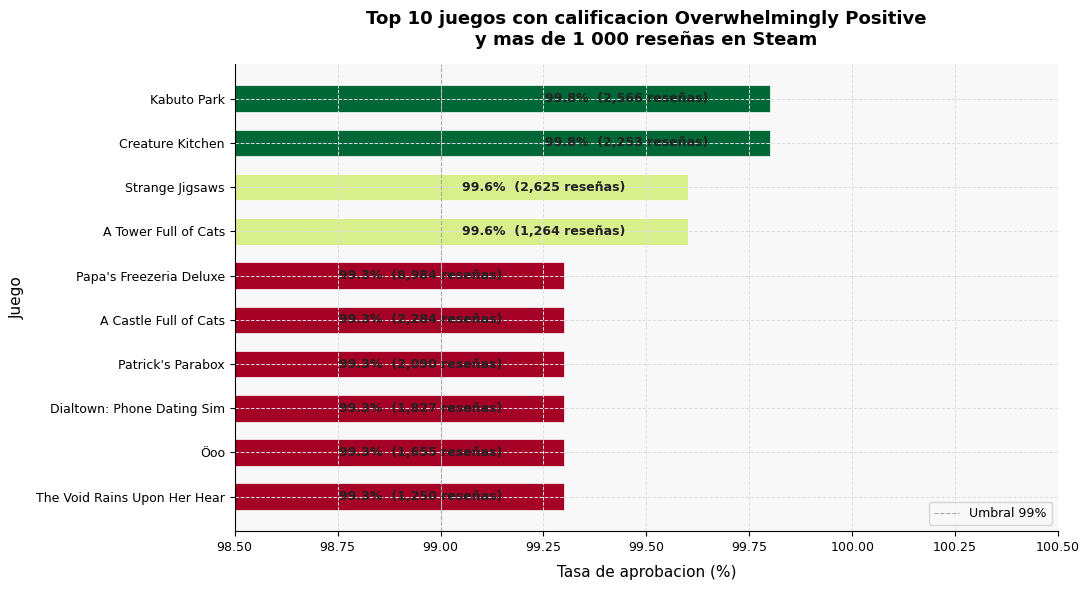

Grafica 1 guardada.


In [31]:
# Filtramos los juegos con Overwhelmingly Positive (ReviewScore 9)
# y mas de 1000 reseñas para garantizar que el puntaje sea representativo.
q1 = (
    df_games[
        (df_games['ReviewScore'] == 9) &
        (df_games['total_reviews'] >= 1000)
    ]
    .sort_values(['approval_rate', 'total_reviews'], ascending=[False, False])
    .head(10)
    .copy()
)
# Acortamos nombres largos para que quepan en el eje
q1['nombre_corto'] = q1['Name'].str[:28]

fig, ax = plt.subplots(figsize=(11, 6))

colores = plt.cm.RdYlGn(
    (q1['approval_rate'].values - q1['approval_rate'].min()) /
    (q1['approval_rate'].max() - q1['approval_rate'].min())
)

barras = ax.barh(
    q1['nombre_corto'][::-1],
    q1['approval_rate'][::-1],
    color=colores[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.6
)

# Etiquetas con el porcentaje y el total de reseñas al final de cada barra
for barra, (_, fila) in zip(barras, q1[::-1].iterrows()):
    ax.text(
        barra.get_width() - 0.15,
        barra.get_y() + barra.get_height() / 2,
        f"{fila['approval_rate']}%  ({fila['total_reviews']:,} reseñas)",
        va='center', ha='right', fontsize=9, color='#222222', fontweight='bold'
    )

ax.set_xlim(98.5, 100.5)
ax.set_xlabel('Tasa de aprobacion (%)', fontsize=11, labelpad=8)
ax.set_ylabel('Juego', fontsize=11, labelpad=8)
ax.set_title(
    'Top 10 juegos con calificacion Overwhelmingly Positive\ny mas de 1 000 reseñas en Steam',
    fontsize=13, fontweight='bold', pad=14
)
ax.axvline(99, color='#aaaaaa', linestyle='--', linewidth=0.8, label='Umbral 99%')
ax.legend(fontsize=9, loc='lower right')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('grafica_1_mejores_valorados.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 1 guardada.")


**Interpretacion**

Los juegos mejor valorados de Steam son en su mayoria titulos independientes de nicho con comunidades pequeñas pero muy fieles.
Kabuto Park y Creature Kitchen lideran con un 99.8% de aprobacion.
Llama la atencion que ninguno de estos titulos supera las 10 000 reseñas — los grandes AAA con millones de jugadores rara vez alcanzan estos porcentajes porque las comunidades masivas tienden a ser mas criticas y diversas en sus opiniones.


---
## Pregunta 2 — Que generos tienen el precio promedio mas alto?


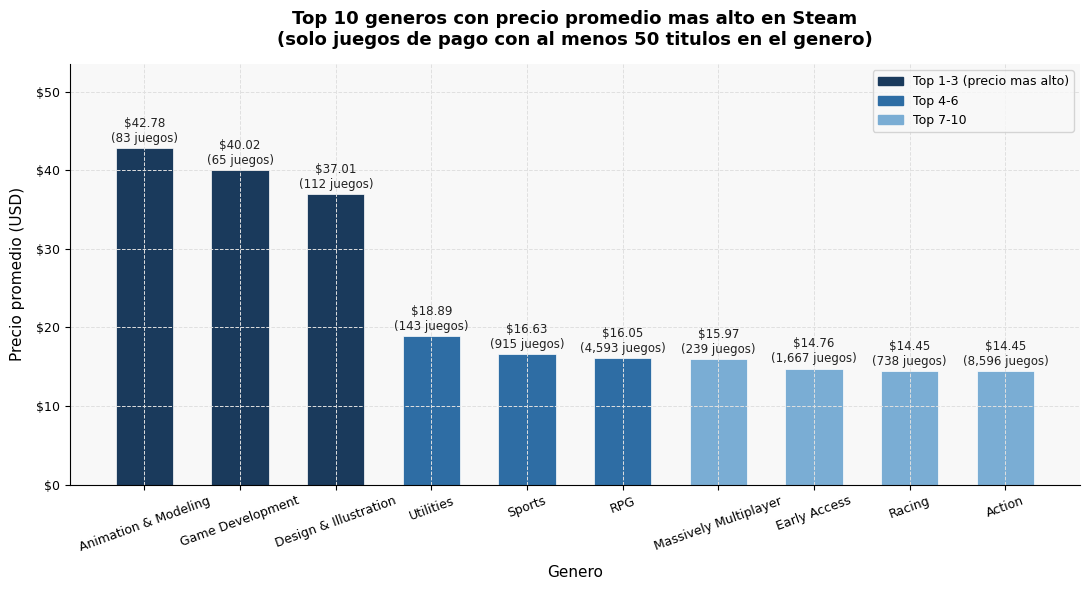

Grafica 2 guardada.


In [32]:
# Explotamos la columna Genres para que cada juego pueda contar en varios generos.
generos_precio = (
    df_games.assign(genero=df_games['Genres'].str.split(','))
    .explode('genero')
    .assign(genero=lambda x: x['genero'].str.strip())
)
q2 = (
    generos_precio[generos_precio['precio'] > 0]
    .groupby('genero')['precio']
    .agg(promedio='mean', cantidad='count')
    .query('cantidad >= 50')
    .sort_values('promedio', ascending=False)
    .head(10)
    .round(2)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

paleta = ['#1a3a5c' if i < 3 else '#2e6da4' if i < 6 else '#7aadd4' for i in range(len(q2))]

barras = ax.bar(
    q2['genero'],
    q2['promedio'],
    color=paleta,
    edgecolor='white',
    linewidth=0.5,
    width=0.6
)

# Etiqueta encima de cada barra con el precio promedio y el numero de juegos
for barra, (_, fila) in zip(barras, q2.iterrows()):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.4,
        f"${fila['promedio']:.2f}\n({fila['cantidad']:,} juegos)",
        ha='center', va='bottom', fontsize=8.5, color='#222222'
    )

ax.set_xlabel('Genero', fontsize=11, labelpad=8)
ax.set_ylabel('Precio promedio (USD)', fontsize=11, labelpad=8)
ax.set_title(
    'Top 10 generos con precio promedio mas alto en Steam\n(solo juegos de pago con al menos 50 titulos en el genero)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_ylim(0, q2['promedio'].max() * 1.25)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0f'))
ax.tick_params(axis='x', labelsize=9, rotation=20)
ax.tick_params(axis='y', labelsize=9)

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1a3a5c', label='Top 1-3 (precio mas alto)'),
    Patch(color='#2e6da4', label='Top 4-6'),
    Patch(color='#7aadd4', label='Top 7-10'),
]
ax.legend(handles=leyenda, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('grafica_2_precio_genero.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 2 guardada.")


**Interpretacion**

Los generos con precios mas altos no son los videojuegos tradicionales sino software de productividad y herramientas creativas: Animation & Modeling ($42.78), Game Development ($40.02) y Design & Illustration ($37.01).
Esto tiene sentido porque son herramientas profesionales que se venden a un precio de software de negocio, no de entretenimiento.
Entre los videojuegos propiamente dichos, Sports, RPG y Racing lideran con precios alrededor de los $15-16, que corresponde al rango estandar de juegos medianos en Steam.


---
## Pregunta 3 — Crecio la cantidad de juegos publicados en Steam año a año?


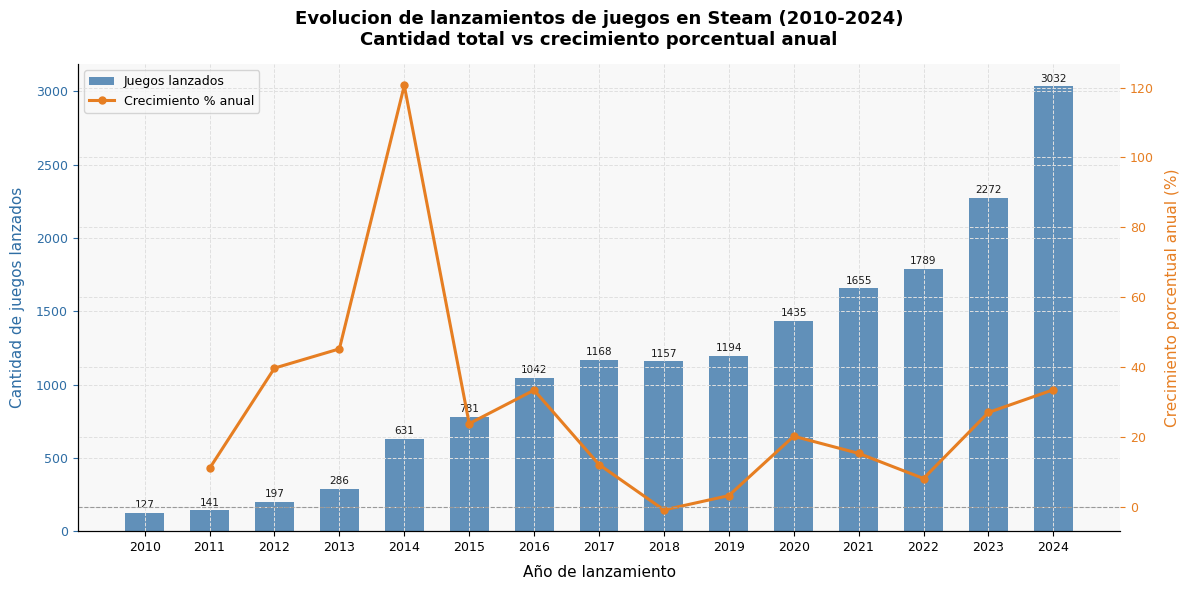

Grafica 3 guardada.


In [33]:
crecimiento = (
    df_games[df_games['año_lanzamiento'].between(2010, 2024)]
    .groupby('año_lanzamiento')
    .size()
    .reset_index(name='juegos')
)
crecimiento['crecimiento_%'] = crecimiento['juegos'].pct_change().mul(100).round(1)
crecimiento['año'] = crecimiento['año_lanzamiento'].astype(int)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()  # segundo eje Y para el porcentaje de crecimiento

# Barras — cantidad de juegos lanzados por año
colores_barra = ['#d94f3d' if c < 0 else '#2e86c1' for c in crecimiento['crecimiento_%'].fillna(0)]
ax1.bar(
    crecimiento['año'],
    crecimiento['juegos'],
    color='#2e6da4',
    alpha=0.75,
    width=0.6,
    label='Juegos lanzados'
)

# Linea — porcentaje de crecimiento año a año
ax2.plot(
    crecimiento['año'],
    crecimiento['crecimiento_%'],
    color='#e67e22',
    linewidth=2.2,
    marker='o',
    markersize=5,
    label='Crecimiento % anual'
)
ax2.axhline(0, color='#999999', linestyle='--', linewidth=0.8)

# Etiquetas de cantidad encima de cada barra
for _, fila in crecimiento.iterrows():
    ax1.text(
        fila['año'], fila['juegos'] + 20,
        str(int(fila['juegos'])),
        ha='center', va='bottom', fontsize=7.5, color='#1a1a1a'
    )

ax1.set_xlabel('Año de lanzamiento', fontsize=11, labelpad=8)
ax1.set_ylabel('Cantidad de juegos lanzados', fontsize=11, labelpad=8, color='#2e6da4')
ax2.set_ylabel('Crecimiento porcentual anual (%)', fontsize=11, labelpad=8, color='#e67e22')
ax1.set_title(
    'Evolucion de lanzamientos de juegos en Steam (2010-2024)\nCantidad total vs crecimiento porcentual anual',
    fontsize=13, fontweight='bold', pad=14
)
ax1.tick_params(axis='x', labelsize=9)
ax1.tick_params(axis='y', labelsize=9, colors='#2e6da4')
ax2.tick_params(axis='y', labelsize=9, colors='#e67e22')
ax1.set_xticks(crecimiento['año'])

lineas1, etiq1 = ax1.get_legend_handles_labels()
lineas2, etiq2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiq1 + etiq2, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('grafica_3_lanzamientos_año.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 3 guardada.")


**Interpretacion**

El catalogo de Steam creció de forma muy agresiva entre 2013 y 2014, cuando se duplico la cantidad de juegos lanzados (crecimiento del 120.6%).
Este pico coincide con la apertura de Steam Greenlight, que bajo drasticamente la barrera de entrada para desarrolladores independientes.
A partir de 2018 el crecimiento se estabilizo e incluso fue ligeramente negativo, posiblemente por la introduccion de Steam Direct, que impuso un costo minimo de publicacion para filtrar proyectos de baja calidad.
El repunte de 2023 y 2024 sugiere una nueva ola de lanzamientos, probablemente impulsada por herramientas de desarrollo accesibles como Unity y Godot.


---
## Pregunta 4 — Los juegos mas caros tienen mejores reseñas que los baratos?


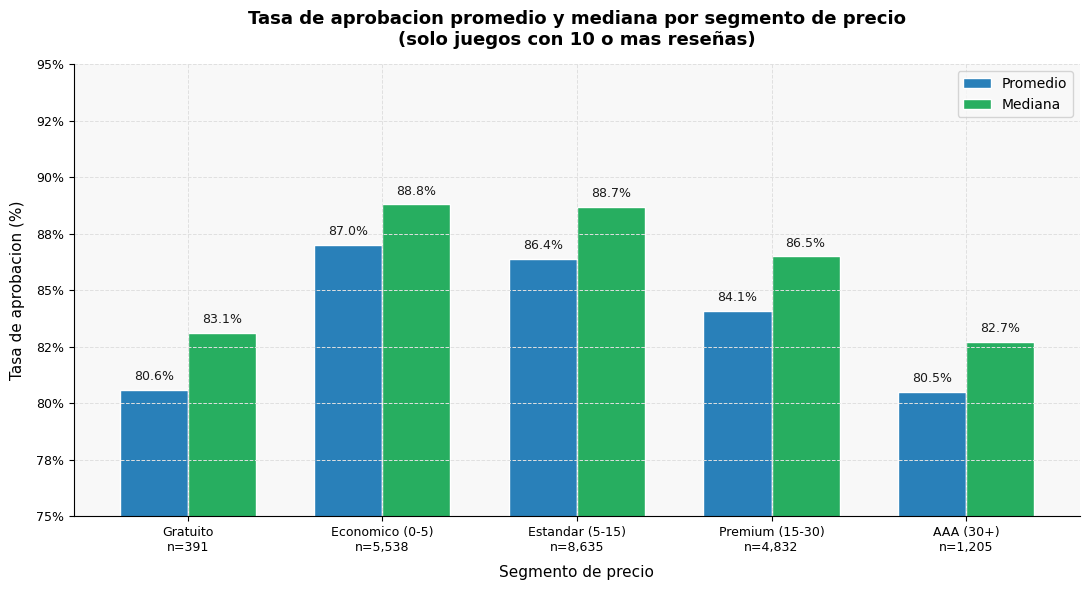

Grafica 4 guardada.


In [34]:
q4 = (
    df_con_reseñas.groupby('segmento_precio', observed=True)['approval_rate']
    .agg(promedio='mean', mediana='median', cantidad='count')
    .round(1)
    .reset_index()
)
q4['etiqueta'] = q4['segmento_precio'].astype(str)

x = np.arange(len(q4))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_prom = ax.bar(
    x - ancho/2, q4['promedio'],
    width=ancho, color='#2980b9', label='Promedio', edgecolor='white')
barras_med  = ax.bar(
    x + ancho/2, q4['mediana'],
    width=ancho, color='#27ae60', label='Mediana', edgecolor='white')

# Etiqueta de porcentaje encima de cada barra
for b in barras_prom:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f"{b.get_height():.1f}%", ha='center', va='bottom', fontsize=9, color='#1a1a1a')
for b in barras_med:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
            f"{b.get_height():.1f}%", ha='center', va='bottom', fontsize=9, color='#1a1a1a')

# Numero de juegos en cada segmento debajo del eje X
etiquetas = [f"{row['etiqueta']}\nn={row['cantidad']:,}" for _, row in q4.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=9)
ax.set_ylim(75, 95)
ax.set_xlabel('Segmento de precio', fontsize=11, labelpad=8)
ax.set_ylabel('Tasa de aprobacion (%)', fontsize=11, labelpad=8)
ax.set_title(
    'Tasa de aprobacion promedio y mediana por segmento de precio\n(solo juegos con 10 o mas reseñas)',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('grafica_4_aprobacion_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 4 guardada.")


**Interpretacion**

Contrario a lo que se podria esperar, los juegos mas caros no son los mejor valorados.
El segmento Economico (0 a 5 dolares) lidera con un promedio del 87.0% de aprobacion, seguido de cerca por Estandar (5-15) con 86.4%.
Los juegos AAA (mas de 30 dolares) y los gratuitos tienen los porcentajes mas bajos, alrededor del 80%.
Esto sugiere que el precio no es un indicador de calidad percibida en Steam.
Los juegos baratos suelen ser propuestas sencillas que cumplen exactamente lo que prometen, mientras que los AAA generan expectativas mucho mas altas que no siempre se satisfacen.


---
## Pregunta 5 — Los juegos con mas reseñas negativas son los peores valorados?


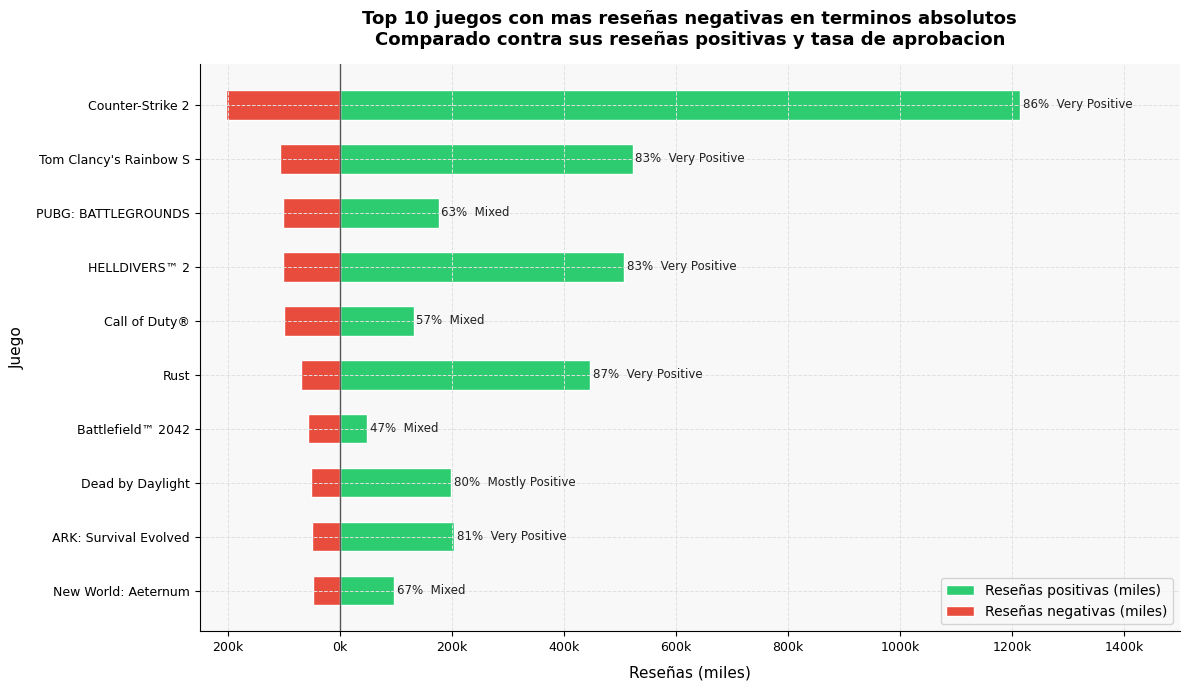

Grafica 5 guardada.


In [35]:
q5 = (
    df_games[df_games['NegativeReview'] > 0]
    [['Name','NegativeReview','PositiveReview','approval_rate','review_label']]
    .sort_values('NegativeReview', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
q5['nombre_corto'] = q5['Name'].str[:22]

color_map = {
    'Overwhelmingly Positive': '#1a7a3a',
    'Very Positive':           '#2ecc71',
    'Mostly Positive':         '#82e0aa',
    'Mixed':                   '#f39c12',
    'Mostly Negative':         '#e74c3c',
    'Negative':                '#922b21',
}
colores = [color_map.get(r, '#aaaaaa') for r in q5['review_label']]

fig, ax = plt.subplots(figsize=(12, 7))

barras_pos = ax.barh(
    q5['nombre_corto'][::-1],
    q5['PositiveReview'][::-1] / 1000,
    color='#2ecc71', label='Reseñas positivas (miles)', height=0.55, edgecolor='white')
barras_neg = ax.barh(
    q5['nombre_corto'][::-1],
    -q5['NegativeReview'][::-1] / 1000,
    color='#e74c3c', label='Reseñas negativas (miles)', height=0.55, edgecolor='white')

# Etiqueta con la tasa de aprobacion al final de la barra positiva
for barra, (_, fila) in zip(barras_pos, q5[::-1].iterrows()):
    ax.text(
        barra.get_width() + 5,
        barra.get_y() + barra.get_height() / 2,
        f"{fila['approval_rate']:.0f}%  {fila['review_label']}",
        va='center', fontsize=8.5, color='#222222'
    )

ax.axvline(0, color='#555555', linewidth=1)
ax.set_xlabel('Reseñas (miles)', fontsize=11, labelpad=8)
ax.set_ylabel('Juego', fontsize=11, labelpad=8)
ax.set_title(
    'Top 10 juegos con mas reseñas negativas en terminos absolutos\nComparado contra sus reseñas positivas y tasa de aprobacion',
    fontsize=13, fontweight='bold', pad=14
)

# Formato del eje X en valores absolutos
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}k"))
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(-250, 1500)

plt.tight_layout()
plt.savefig('grafica_5_resenñas_negativas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica 5 guardada.")


**Interpretacion**

Los 10 juegos con mas reseñas negativas en terminos absolutos no son los peores de Steam — la mayoria tiene calificacion Very Positive o Mostly Positive.
Counter-Strike 2 lidera con 202 000 reseñas negativas, pero su tasa de aprobacion es del 85.7%.
Esto demuestra que el volumen absoluto de criticas negativas no refleja la calidad del juego sino su popularidad: cuantos mas jugadores tiene un titulo, mas reseñas recibe en ambas direcciones.
Los casos mas preocupantes son Battlefield 2042 (46.7%) y Call of Duty (57.2%), que si muestran una insatisfaccion real de su base de jugadores a pesar de ser titulos de grandes estudios.
